In [1]:
# Imports necessary packages
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

In [2]:
# Paths and plot settings
mutation_path = "CCLE_mutations.csv"
sample_info_path = Path("sample_info.csv")

nmf_paths = {
    "RNF125": "RNF125_nmfinfo_final.csv",
    "PRMT6": "PRMT6_nmfinfo_final.csv",
}

# Update the NRF2 path here if your NRF2 GSEA file lives somewhere else.
gsea_paths = {
    "NRF2": "NRF2_GSEA.csv",
    "PI3K": "HALLMARK_PI3K_AKT_MTOR_SIGNALING_GSEA.csv",
}

gsea_columns = {
    "NRF2": "SINGH_NFE2L2_TARGETS",
    "PI3K": "HALLMARK_PI3K_AKT_MTOR_SIGNALING",
}

# Compare any mutation in each protein against all other cell lines.
plot_order = ["Protein mutations", "Other cell lines"]

In [3]:
# Helper functions
def p_to_star(p_value):
    """Convert a p-value to a standard significance star label."""
    if p_value < 1e-4:
        return "****"
    if p_value < 1e-3:
        return "***"
    if p_value < 1e-2:
        return "**"
    if p_value < 5e-2:
        return "*"
    return "ns"


def zscore(series):
    """Z-score a pandas Series while ignoring missing values."""
    return (series - series.mean()) / series.std(ddof=0)


def load_gsea(path, score_col):
    """Load one GSEA file and return CCLE_Name plus a z-scored pathway score."""
    df = pd.read_csv(path)

    if "CCLE_Name" not in df.columns:
        df = df.rename(columns={"Unnamed: 0": "CCLE_Name"})

    if score_col not in df.columns:
        raise ValueError(
            f"Could not find score column '{score_col}' in {path}. "
            f"Available columns: {df.columns.tolist()}"
        )

    df = df[["CCLE_Name", score_col]].copy()
    df[score_col] = zscore(df[score_col])
    return df


def get_mutant_cell_lines(mutations, protein):
    """Return CCLE names with any mutation in the selected protein."""
    sub = mutations.loc[
        (mutations["Hugo_Symbol"] == protein) &
        (mutations["CCLE_Name"].notna())
    ]
    return sorted(sub["CCLE_Name"].unique().tolist())


def make_plot_df(gsea_df, score_col, mutant_cell_lines):
    """Create long-form data for plotting protein-mutant vs other cell lines."""
    df = gsea_df.copy()
    df["group"] = np.where(
        df["CCLE_Name"].isin(mutant_cell_lines),
        "Protein mutations",
        "Other cell lines",
    )
    return df.rename(columns={score_col: "GSEA score"})


def plot_gsea_comparison(plot_df, protein, pathway, ax=None):
    """Make a clean box/strip plot with no statistical annotations."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.2, 4.5))

    sns.boxplot(
        data=plot_df,
        x="group",
        y="GSEA score",
        order=plot_order,
        showfliers=False,
        ax=ax,
    )
    sns.stripplot(
        data=plot_df,
        x="group",
        y="GSEA score",
        order=plot_order,
        color="black",
        alpha=0.35,
        size=3,
        jitter=0.2,
        ax=ax,
    )

    ax.set_title(f"{protein}: {pathway} GSEA")
    ax.set_xlabel("")
    ax.set_ylabel("Z-scored GSEA score")
    ax.tick_params(axis="x", rotation=25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return ax

In [4]:
# Load mutation data and map DepMap IDs to CCLE names
mutations = pd.read_csv(mutation_path)
mutations["pos"] = mutations["Protein_Change"].str.extract(r"(\d+)").astype("Int64")

sample_info = pd.read_csv(sample_info_path)
id_to_name = sample_info.set_index("DepMap_ID")["CCLE_Name"].to_dict()
mutations["CCLE_Name"] = mutations["DepMap_ID"].map(id_to_name)

/tmp/kritis/46897236/c0300ood18.ll.unc.edu/ipykernel_2913926/4073253353.py:2: DtypeWarning: Columns (3,19,22,27,28,29,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  mutations = pd.read_csv(mutation_path)


In [5]:
# Load GSEA scores
gsea_data = {
    pathway: load_gsea(gsea_paths[pathway], gsea_columns[pathway])
    for pathway in gsea_paths
}

{pathway: df.shape for pathway, df in gsea_data.items()}

{'NRF2': (1210, 2), 'PI3K': (1412, 2)}

In [6]:
# Get cell lines with RNF125 or PRMT6 mutation
mutant_cell_lines = {
    protein: get_mutant_cell_lines(mutations, protein)
    for protein in nmf_paths
}

summary = pd.DataFrame({
    "protein": list(mutant_cell_lines),
    "n_mutant_cell_lines": [len(mutant_cell_lines[p]) for p in mutant_cell_lines],
})


In [7]:
# Build plot data for all protein/pathway combinations
plot_data = {}

for protein in ["RNF125", "PRMT6"]:
    for pathway in ["NRF2", "PI3K"]:
        score_col = gsea_columns[pathway]
        plot_data[(protein, pathway)] = make_plot_df(
            gsea_data[pathway],
            score_col,
            mutant_cell_lines[protein],
        )

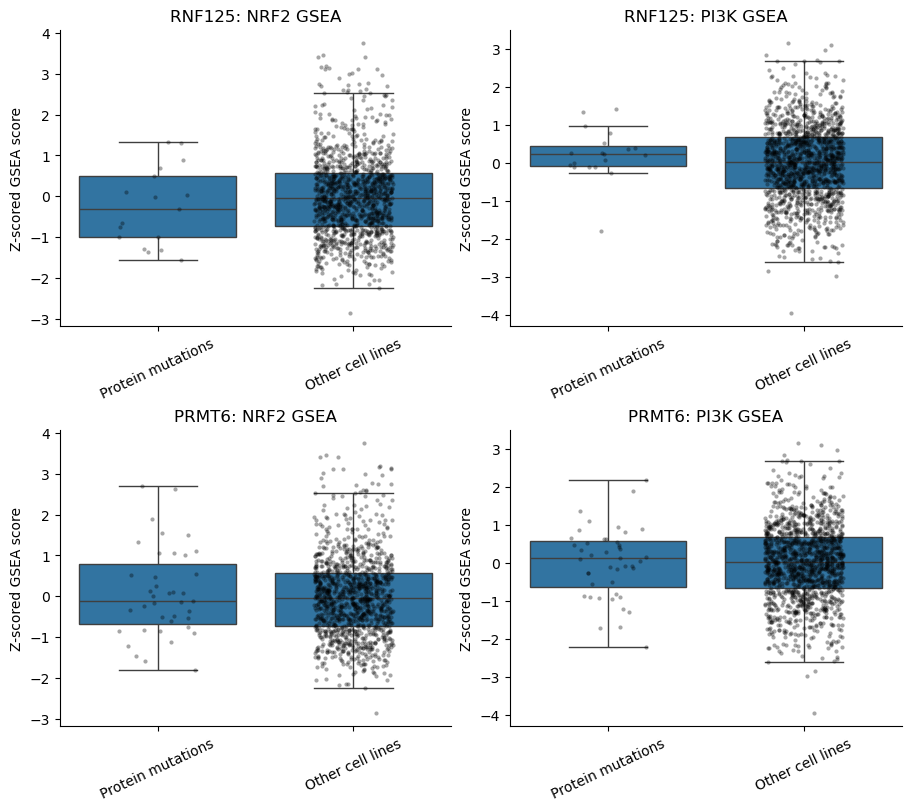

In [8]:
# Plot all four comparisons
fig, axes = plt.subplots(2, 2, figsize=(9, 8), constrained_layout=True)

for ax, (protein, pathway) in zip(axes.ravel(), plot_data):
    plot_gsea_comparison(plot_data[(protein, pathway)], protein, pathway, ax=ax)

plt.show()